# Binomial Distribution Simulation

## What This Notebook Is About

This notebook explores the **Binomial Distribution** — one of the most important probability distributions in statistics.

---

### The Binomial Distribution (in plain English)

Imagine a repeated experiment where each trial has exactly two outcomes: **success** or **failure** (heads/tails, pass/fail, click/no-click, defective/not-defective).

**The binomial distribution answers**: "If the probability of success on each trial is *p*, and I run *n* trials, how many successes should I expect to see?"

**Real-world examples:**
- 100 website visitors, each 10% likely to click a button → how many clicks?
- 50 coin flips → how many heads?
- 1,000 emails sent, 0.5% chance each one bounces → how many bounces?

### Two Parameters Control Everything

| Parameter | Meaning | Effect |
|---|---|---|
| **p** | Probability of *success* on one trial | Controls *where* the distribution centres; extreme values (near 0 or 1) make it skewed |
| **n** | Number of trials per experiment | Controls *width* and *shape*; as n grows, the distribution approaches a normal curve |

---

### The Normal Approximation

When both `n * p > 5` **and** `n * (1 − p) > 5`, the binomial can be well-approximated by a normal distribution. This notebook explores *when* that approximation holds and when it breaks down. A black KDE line is added to panels where the approximation is valid.

---

### What You Will Learn

| Concept | Where |
|---|---|
| `np.random.binomial`: simulate coin-flip-style experiments | Section 3 |
| Building a tidy long-format DataFrame | Section 3 |
| FacetGrid with rows **and** columns | Section 4 |
| Conditional KDE overlay (normal approximation check) | Section 4 |
| Reading a grid of distributions | Section 4 |

---

### Libraries Used
- **`numpy`** — fast binomial random number generation
- **`pandas`** — organise results into a tidy DataFrame
- **`seaborn`** — FacetGrid visualisations
- **`matplotlib`** — plot customisation

## 1. Import Libraries

In [1]:
import numpy as np              # Efficient random number generation; np.random.binomial()
import pandas as pd             # Organise results into a tidy DataFrame
import seaborn as sns           # FacetGrid visualisations (grid of small multiples)
import matplotlib.pyplot as plt  # Core plotting: figure sizing, titles

# sns.set_style("ticks"): clean style with tick marks on the axes.
# Other options: "whitegrid", "darkgrid", "white", "dark"
sns.set_style("ticks")


## 2. Simulation Parameters

Change these to explore different scenarios.

In [2]:
# Probability of success on a single trial
probabilities = [0.01, 0.1, 0.5, 0.7]

# Number of trials in each experiment
num_trials = [1, 5, 10, 100, 1000]

# How many times we repeat each experiment
# More simulations = smoother histogram, but slower to run
num_simulations = 10_000

print(f"Total experiments to simulate: {len(probabilities) * len(num_trials)}")
print(f"Total rows in results DataFrame: {len(probabilities) * len(num_trials) * num_simulations:,}")

Total experiments to simulate: 20
Total rows in results DataFrame: 200,000


## 3. Run Simulations

For each combination of (p, n) we use `np.random.binomial` to simulate `num_simulations` experiments at once.

Each value in the result is the number of successes out of `n` trials, with each trial having probability `p` of success.

In [3]:
# We'll collect results from every (p, n) combination here.
# Each item will be a small DataFrame; we'll stack them at the end.
all_results = []

print("Running simulations...")

# Nested loop: outer loop over p values, inner loop over n values.
# For each of the 4×5 = 20 combinations, we run 10,000 simulations.
for p in probabilities:
    for n in num_trials:
        # ── THE KEY FUNCTION: np.random.binomial(n, p, size) ──────────────
        # Simulates flipping a (possibly unfair) coin `n` times, where each
        # flip has probability `p` of being "heads" (a success).
        # Returns the NUMBER OF SUCCESSES.
        #
        # Arguments:
        #   n    = number of trials per experiment (e.g. 100 coin flips)
        #   p    = probability of success on each trial (e.g. 0.5 = fair coin)
        #   size = how many experiments to simulate at once (vectorised!)
        #
        # Returns: an array of length `size` where each value = successes in n trials
        # Example: np.random.binomial(10, 0.5, size=5)
        #          might return [6, 4, 5, 7, 3]
        #          meaning: 6 heads, 4 heads, 5 heads, 7 heads, 3 heads
        success_counts = np.random.binomial(n, p, size=num_simulations)

        # Build a small DataFrame for this (p, n) combination.
        # We record all three values so we can filter by them later.
        # This is "tidy" format: each row = one experiment outcome.
        all_results.append(pd.DataFrame({
            'num_successes':   success_counts,  # the result of each experiment
            'probability_p':   p,               # which p value was used
            'num_trials_n':    n                # which n value was used
        }))

# pd.concat stacks a list of DataFrames vertically (one on top of the other).
# ignore_index=True resets the row numbers to 0, 1, 2, ... in the combined table.
# Final result: 20 combinations × 10,000 rows = 200,000 rows total
df_results = pd.concat(all_results, ignore_index=True)

print(f"Done. DataFrame shape: {df_results.shape}")
df_results.head(10)


Running simulations...
Done. DataFrame shape: (200000, 3)


,num_successes,probability_p,num_trials_n
0,0,0.01,1
1,0,0.01,1
2,0,0.01,1
3,0,0.01,1
4,0,0.01,1
5,0,0.01,1
6,0,0.01,1
7,0,0.01,1
8,0,0.01,1
9,0,0.01,1


## 4. Visualise

### Grid layout
Each **row** = one value of p | Each **column** = one value of n

### Normal approximation overlay
A black KDE line is added when **both** conditions hold:
- `n * p > 5`
- `n * (1 - p) > 5`

These are the standard conditions under which the binomial distribution is well-approximated by a normal. When either condition fails (e.g. very small p or very small n), the distribution is skewed and the normal approximation is not appropriate.

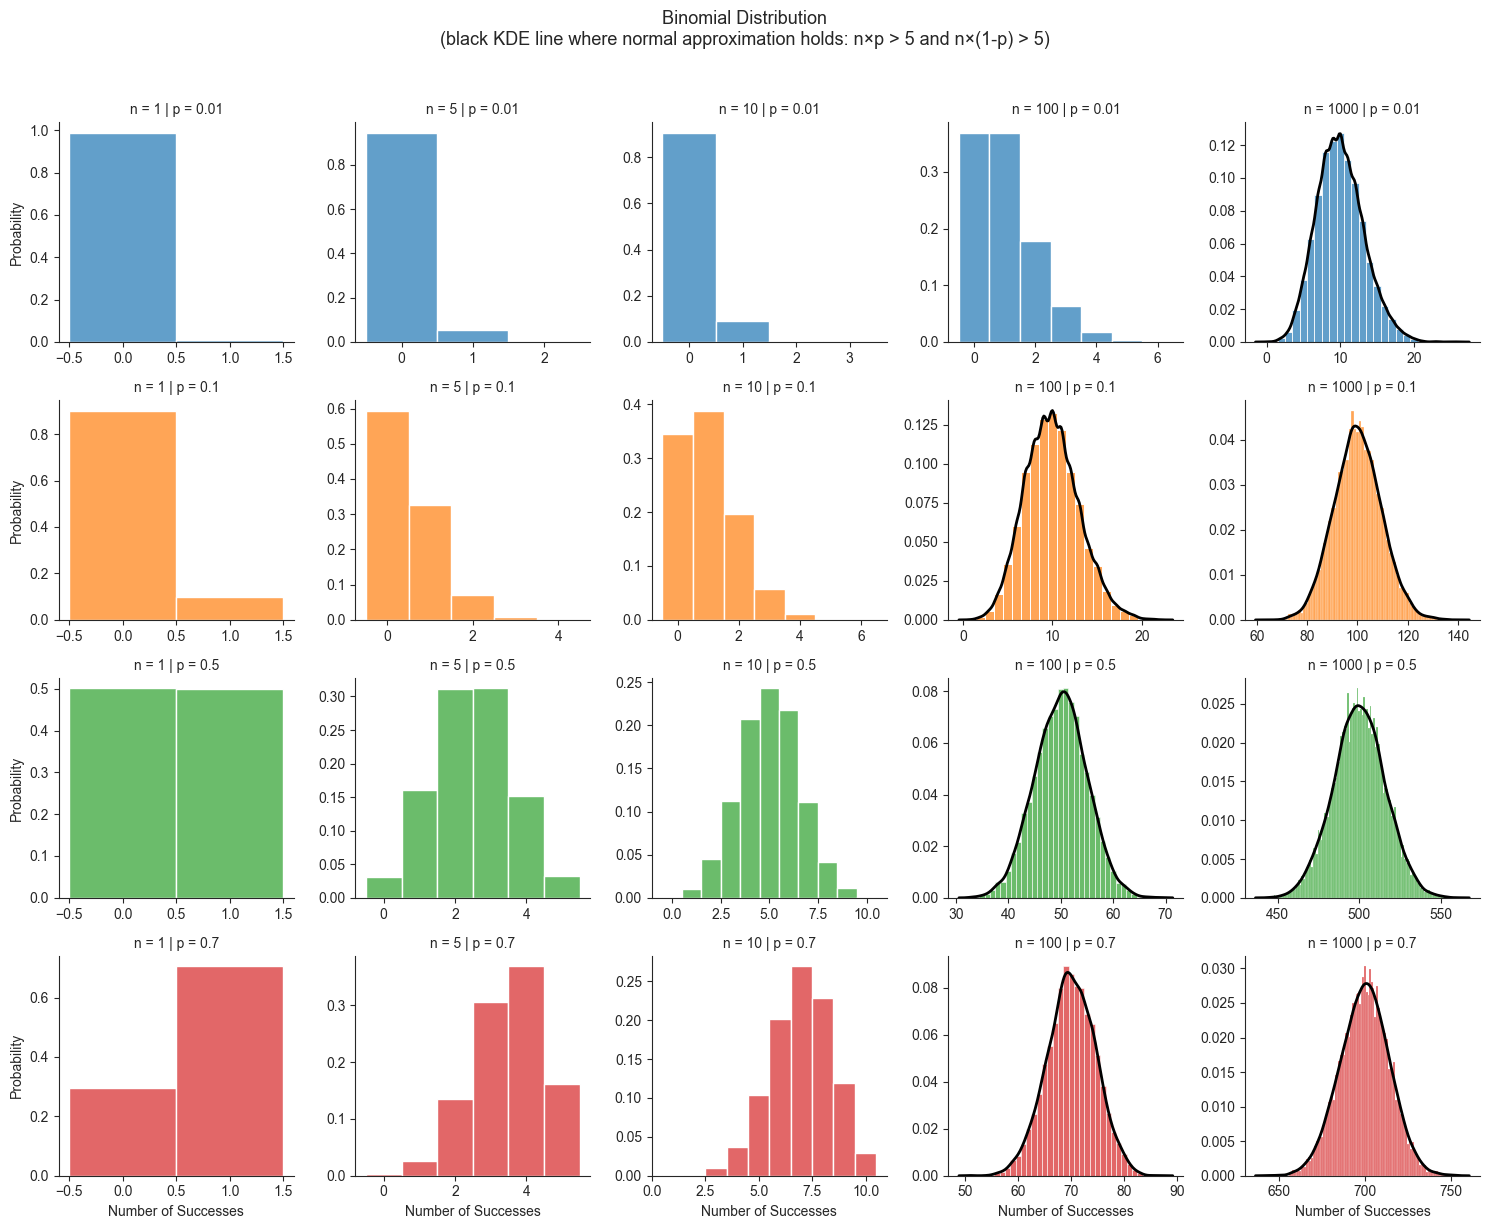

In [4]:
# ── BUILD THE FACETGRID ───────────────────────────────────────────────────────
#
# FacetGrid creates a GRID of small plots. Think of it like a matrix of charts:
#   rows    → one row per value of 'probability_p'     (p = 0.01, 0.1, 0.5, 0.7)
#   columns → one column per value of 'num_trials_n'   (n = 1, 5, 10, 100, 1000)
#   → Total: 4 × 5 = 20 panels
#
# sharex=False: each panel can have its own x-axis range.
#   (Needed because p=0.01, n=1000 has successes clustered near 10,
#    while p=0.5, n=1000 has successes spread from ~450 to ~550)
# sharey=False: each panel can have its own y-axis scale.
# hue='probability_p': colour-codes by p value for easy visual distinction.
g = sns.FacetGrid(
    data=df_results,
    row='probability_p',
    col='num_trials_n',
    hue='probability_p',
    sharex=False,
    sharey=False
)

# ── DRAW HISTOGRAMS on every panel ───────────────────────────────────────────
# g.map_dataframe() calls the given function on each (p, n) subset of data.
# seaborn figures out which subset belongs to which panel automatically.
#
# stat='probability' → y-axis is P(X = x), not raw counts. Allows comparison.
# discrete=True → one bar per integer value (since successes are whole numbers)
# alpha=0.7 → slightly transparent bars (0 = invisible, 1 = fully solid)
g.map_dataframe(
    sns.histplot,
    x='num_successes',
    stat='probability',
    discrete=True,
    alpha=0.7
)

# ── CONDITIONALLY ADD A KDE LINE (normal approximation) ──────────────────────
# We loop over every panel and check the two conditions:
#   n*p > 5      → enough expected successes
#   n*(1-p) > 5  → enough expected failures
# BOTH must hold for the normal approximation to be valid.
# Only then do we add a smooth KDE curve to show the approximate normal shape.
#
# g.axes_dict: a dictionary mapping (p, n) tuples → the corresponding Axes object
# This allows us to access and modify individual panels.
for (p, n), ax in g.axes_dict.items():
    if n * p > 5 and n * (1 - p) > 5:
        # Filter the FULL DataFrame to only the rows for this (p, n) combination.
        # The boolean mask uses & (AND) to require BOTH conditions to be True.
        facet_data = df_results[
            (df_results['probability_p'] == p) &
            (df_results['num_trials_n'] == n)
        ]
        # sns.kdeplot draws a smooth density curve.
        # ax=ax is CRITICAL: it pins the curve to THIS specific panel.
        # Without ax=ax, seaborn might draw it on the wrong panel or a new figure.
        sns.kdeplot(
            data=facet_data,
            x='num_successes',
            color='black',
            linewidth=2,
            ax=ax           # <── this ties the plot to the correct panel
        )

# ── LABELS AND TITLES ─────────────────────────────────────────────────────────
g.fig.suptitle(
    'Binomial Distribution\n(black KDE line where normal approximation holds: n×p > 5 and n×(1-p) > 5)',
    fontsize=13, y=1.02
)
g.set_titles("n = {col_name} | p = {row_name}")   # {col_name} and {row_name} auto-filled
g.set_axis_labels("Number of Successes", "Probability")

plt.tight_layout()
plt.show()


## 5. Key Takeaways

| Condition | What you see |
|---|---|
| Small p, small n (e.g. p=0.01, n=1) | Almost all mass at 0, very right-skewed |
| Large n, p=0.5 | Symmetric bell curve, KDE line fits well |
| Large n, small p (e.g. p=0.01, n=1000) | np=10 > 5, so normal approx works |
| Small n regardless of p | Discrete spikes, KDE line absent or misleading |

**Central Limit Theorem in action**: as *n* increases, the binomial converges to a normal distribution -- but only when *n* is large enough relative to p.